In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Разведочный анализ данных для hirehi. 

In [3]:
palette = ["#1f2d3a", "#0f766e", "#2a4d69"]

### Работа с исходными данными

In [74]:
data = pd.read_csv('vacancys_final.csv')
data.sample(3)

,Unnamed: 0,id,title,category,company,format,level,salary,link,skills
7094,7094,27964,data analyst,analytics,NDA,офис Узбекистан,middle,~ от 136 200 ₽,https://hirehi.ru/analytics/data-analyst-27964,"['sql', 'аналитическое мышление', 'английский'..."
1820,1820,34797,QA Engineer (manual),qa,Авито,удалённо,intern,~ от 60 800 ₽,https://hirehi.ru/qa/qa-engineer-manual-34797,"['python', 'java', 'go', 'javascript', 'sql', ..."
4173,4173,32066,product owner,management,NDA,офис Алматы,middle,~ от 194 600 ₽,https://hirehi.ru/management/product-owner-32066,"['product owner', 'финтех', 'интернет-банкинг'..."


Оценим, как распределено количество требуемых инструментов для различных вакансий. Для этого создадим дополнительный признак - `skills_num`.

In [5]:
def get_len(x):
    if x == '[]':
        return 0
    return len(x[1:-2].split(', '))

In [6]:
data['skills_num'] = data['skills'].apply(lambda x: get_len(x))
skills_length_grouped = data['skills_num'].value_counts()
skills_length_grouped

skills_num
10    1353
15    1199
12    1198
14    1193
13     981
11     959
9      443
8      347
7      246
16     238
6      176
5      112
4       65
17      61
0       55
20      39
18      29
3       27
19      18
2       11
1        4
Name: count, dtype: int64

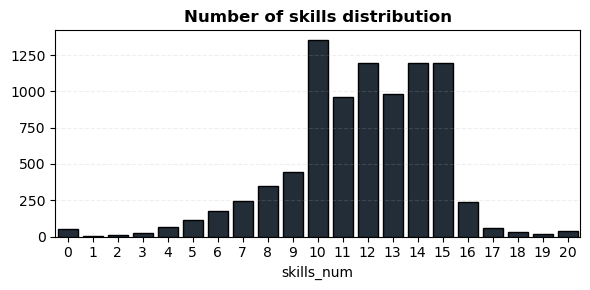

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    color=palette[0],
    edgecolor='black'
)
ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_title('Number of skills distribution', fontweight='bold')
plt.tight_layout()

Большинство вакансий требуют от 10 до 15 навыков. При этом наблюдается небольшое число вакансий, для которых навыки не требуются - скорее всего карточка не заполнена

Посмотрим на распределение количества необходимых навыков относительно различных направлений:

In [8]:
data_grouped = data.groupby('category')['skills_num'].mean()
data_grouped

category
analytics      11.633962
design         10.543161
development    11.922481
devops         13.572148
management     11.214158
marketing      10.518265
qa             12.278993
Name: skills_num, dtype: float64

Посмотрим на зависимость количества скиллов от грейда специалиста:

In [58]:
level_groupped = data.groupby('level')['skills_num'].mean()
level_groupped

level
head          11.333333
intern         9.232558
junior         9.871795
lead          11.945312
middle        11.591027
senior        12.317902
грейда нет     6.000000
не указан      9.000000
Name: skills_num, dtype: float64

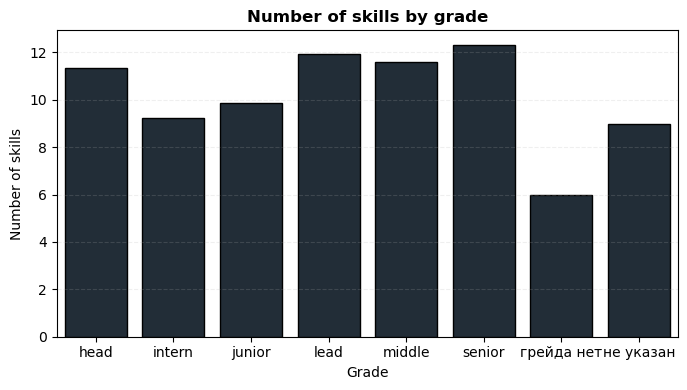

In [84]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=level_groupped, 
    color=palette[0],
    edgecolor='black'
)

ax.set_xlabel('Grade')
ax.set_ylabel('Number of skills')
ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_title('Number of skills by grade', fontweight='bold')
plt.tight_layout()

Посмотрим, какие навыки требуются в самых распространенных вакансиях:

In [ ]:
top_3_vac = data_processed['title'].value_counts().iloc[1:4].index

title
product manager       225
системный аналитик    211
project manager       208
Name: count, dtype: int64

In [161]:
top_3_vac = data_processed['title'].value_counts().iloc[1:4].index
print(f'Топ 3 вакансий: {top_3_vac}')

Топ 3 вакансий: Index(['product manager', 'системный аналитик', 'project manager'], dtype='object', name='title')


In [ ]:
top_n = 5

skill_title = pd.merge( 
    left=data_processed, 
    right=data_skills, 
    on='id' 
)[['title', 'skill']] 
top3_exp = skill_title[skill_title['title'].isin(top_3_vac)] 
top3_exp = top3_exp.groupby(['title', 'skill']).size().reset_index(name='skills_num')
top3_exp = top3_exp.sort_values(['title', 'skills_num'], ascending=False)

data_system_analyst = top3_exp[top3_exp['title'] == 'системный аналитик'].head(top_n)
data_system_analyst

data_product_manager = top3_exp[top3_exp['title'] == 'product manager'].head(top_n)
data_product_manager

data_project_manager = top3_exp[top3_exp['title'] == 'project manager'].head(top_n)
data_project_manager

,title,skill,skills_num
1282,project manager,project management,101
952,project manager,agile,65
1172,project manager,jira,57
1334,project manager,scrum,48
1742,project manager,управление проектами,39


### Работа с расширенными данными

In [9]:
data_skills = pd.read_csv('skills.csv')

In [10]:
data_skills.isna().sum()

id        0
skill    55
dtype: int64

Количество пропущенных не поменялось, поэтому удалим их из рассмотрения

In [11]:
data_skills = data_skills.dropna()

Дубликаты и кардинальность: 

In [12]:
print(f'Наличе дубликатов:              {data_skills.duplicated().any()}')
print(f'Количество уникальных значений: {data_skills['skill'].nunique()}')

Наличе дубликатов:              False
Количество уникальных значений: 10409


Определим самые часто-встречающиеся навыки:

In [13]:
top_n = 15
skill_stats = data_skills['skill'].value_counts().head(top_n).sort_values()
skill_stats

skill
ai             696
redis          701
аналитика      729
jira           753
typescript     797
linux          850
ci/cd          921
api           1048
kafka         1072
kubernetes    1170
git           1291
docker        1512
postgresql    1519
python        2091
sql           2289
Name: count, dtype: int64

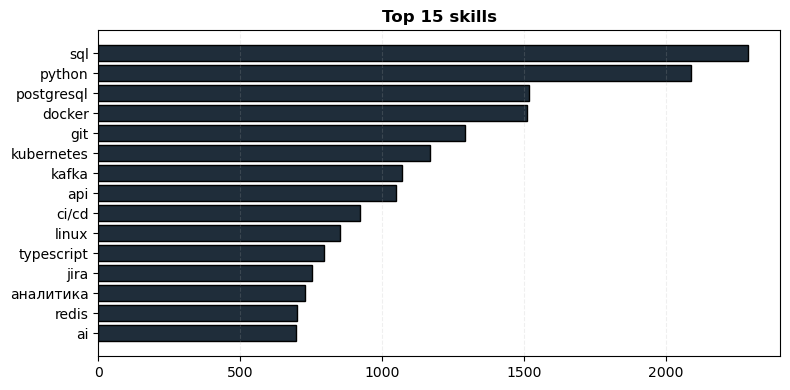

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    y=skill_stats.index,
    width=skill_stats.values,
    edgecolor='black',
    color=palette[0]
)

ax.grid(axis='x', linestyle='--', alpha=0.2)
ax.set_title(f'Top {top_n} skills', fontweight='bold')
plt.tight_layout()

#### Работа с обработанных исходником

In [15]:
data_processed = pd.read_csv('analysys.csv')
data_processed

,id,title,category,company,level,salary,link,format,city/country
0,36700,quality assurance (manual),qa,NDA,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,удалённо,Не указано
2,36697,platform engineer,devops,NDA,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,гибрид,Москва
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,middle,200000,https://hirehi.ru/development/ml-engineer-24856,удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,senior,150000,https://hirehi.ru/development/razrabotchik-php...,офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,удалённо,РФ


company
Сбер           500
Ozon           309
Т1             133
Т-Банк         127
Wildberries    123
Касперский     106
Name: count, dtype: int64

In [16]:
skill_salary = pd.merge(
    left=data_skills,
    right=data_processed,
    on='id'
)[['skill', 'salary']]
skill_salary_grouped = skill_salary.groupby('skill')['salary'].agg(['mean', 'median', 'count'])
skill_salary_grouped

,mean,median,count
skill,,,
.net,271584.210526,250000.0,133
.net 6,150400.000000,150400.0,2
.net 8,235933.333333,250000.0,3
.net core,278777.500000,314400.0,40
.net framework,239187.500000,244750.0,8
...,...,...,...
яндекс.карты,224700.000000,224700.0,1
яндекс.метрика,182357.142857,177100.0,14
яндекс.трекер,150000.000000,150000.0,1


In [55]:
data_processed

,id,title,category,company,level,salary,link,format,city/country
0,36700,quality assurance (manual),qa,NDA,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,удалённо,Не указано
2,36697,platform engineer,devops,NDA,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,гибрид,Москва
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,middle,200000,https://hirehi.ru/development/ml-engineer-24856,удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,senior,150000,https://hirehi.ru/development/razrabotchik-php...,офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,удалённо,РФ
